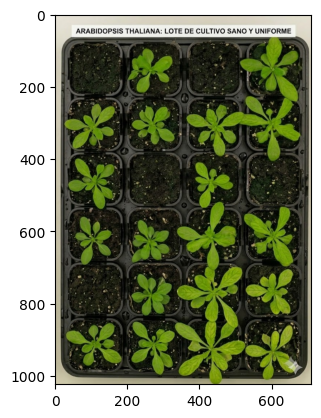

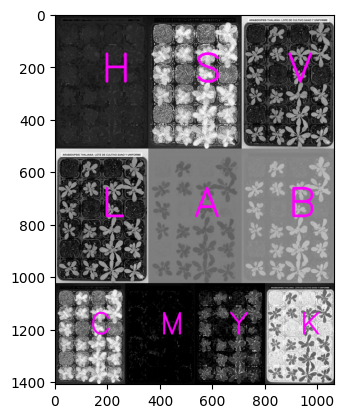

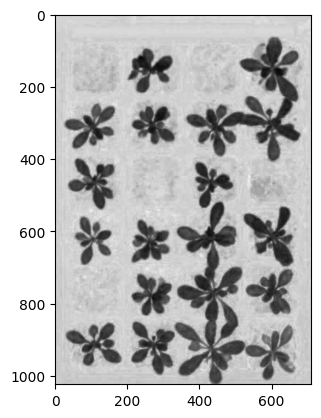

alt.Chart(...)

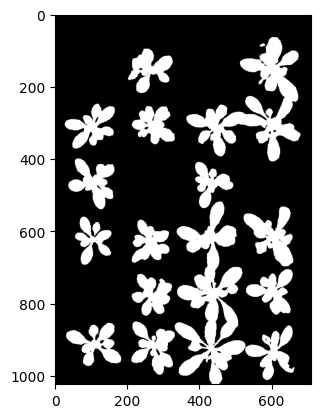

In [ ]:
# Thresholding: https://plantcv.org/tutorials/thresholding-67h77


# Importar librerías necesarias
import numpy as np
from plantcv import plantcv as pcv 
from plantcv.parallel import WorkflowInputs

# Nota: Si vas a correr esto como un script de Python (.py) normal y no en Jupyter, 
# la siguiente línea debe estar comentada (como está ahora). Si usas Jupyter, descoméntala.
# %matplotlib notebook

# Es importante más tarde hacer un parametro para ajusta el tamaño de la bandeja por columnas y filas

# --- Sección 1: Input/Output variables ---
args = WorkflowInputs(
    images=["GeminiConteo4.jpg"], # Asegúrate de que esta ruta sea correcta    
    names="image1",
    result="arabidopsis_results.json",
    outdir=".",
    writeimg=True,
    debug="plot", # Cambia a "None" si no quieres que se abran las ventanas de imágenes
    sample_label="genotype"
)

# Configurar parámetros globales de PlantCV
pcv.params.debug = args.debug
pcv.params.dpi = 100
pcv.params.text_size = 10
pcv.params.text_thickness = 20

# Leer la imagen
img, path, filename = pcv.readimage(filename=args.image1)

# --- Sección 2: Segmentar la planta del fondo ---
# (Opcional) Visualizar espacios de color
colorspaces = pcv.visualize.colorspaces(rgb_img=img, original_img=False)

# Convertir la imagen a escala de grises usando el canal 'a' (verde-magenta) de LAB
a = pcv.rgb2gray_lab(rgb_img=img, channel='a')

# (Opcional) Visualizar el histograma para revisar el umbral
hist = pcv.visualize.histogram(img=a, bins=25)

# Umbralización inversa para aislar las plantas oscuras (píxeles blancos = planta)
# a_thresh = pcv.threshold.binary(gray_img=a, threshold=110, object_type='dark')
# 'object_type="dark"' porque seguimos buscando la planta que es más oscura que el fondo brillante (si usas el canal 'a')
a_thresh = pcv.threshold.otsu(gray_img=a, object_type='dark')


/home/flan/Documents/programming_proyects/AgenteAgricultura/.venv/lib/python3.13/site-packages/plantcv/plantcv/_helpers.py:899: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  return function(sub_img, **kwargs)


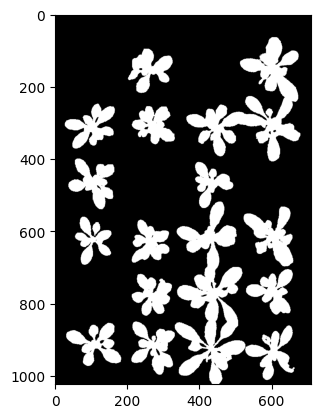

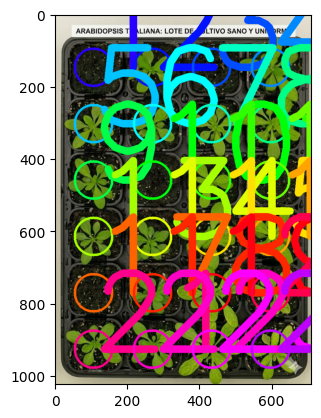

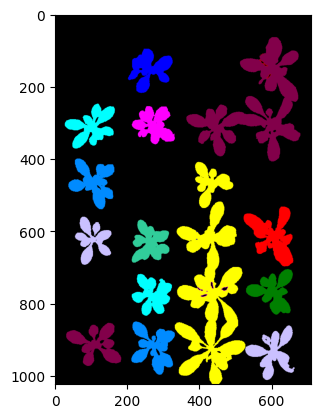


RESULTADO DEL CONTEO:
Se detectaron 19 plantas viables en la bandeja.



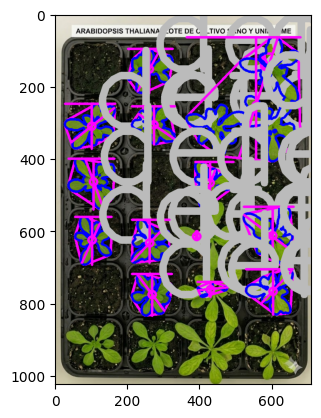

alt.FacetChart(...)

Análisis completado. Resultados guardados en arabidopsis_results.json


In [2]:

# Limpiar el ruido de fondo (eliminar manchas blancas menores a 200 píxeles)
a_fill = pcv.fill(bin_img=a_thresh, size=200)

# --- Sección 3: Definir las Regiones de Interés (ROIs) ---
# Crear una cuadrícula automática de 4 filas x 5 columnas
rois = pcv.roi.auto_grid(mask=a_fill, nrows=6, ncols=4, img=img)

# --- Sección 4: Crear la máscara etiquetada ---
labeled_mask, num_plants = pcv.create_labels(mask=a_fill, rois=rois, roi_type="partial")

# ==========================================================
# --- CONTEO DE PLANTAS Y REGISTRO ---
# ==========================================================

# Encontrar las etiquetas únicas que realmente contienen planta
etiquetas_presentes = np.unique(labeled_mask)

# Contar y restar 1 para ignorar el fondo (que tiene valor 0)
conteo_real = len(etiquetas_presentes) - 1

# Imprimir el resultado en la consola para que lo veas rápidamente
print("\n" + "="*40)
print(f"RESULTADO DEL CONTEO:")
print(f"Se detectaron {conteo_real} plantas viables en la bandeja.")
print("="*40 + "\n")

# ¡Clave! Añadir esta observación a los outputs para que se guarde en el JSON
pcv.outputs.add_observation(sample='image1', 
                            variable='plant_count', 
                            trait='number of detected plants', 
                            method='count', 
                            scale='plants', 
                            datatype=int, 
                            value=conteo_real, 
                            label='plants')
# ==========================================================

# --- Sección 5: Medir cada planta ---
# Medir tamaño y forma
shape_img = pcv.analyze.size(img=img, labeled_mask=labeled_mask, n_labels=20)

# Medir color
color_img = pcv.analyze.color(rgb_img=img, labeled_mask=labeled_mask, n_labels=20, colorspaces="HSV")

# --- Guardar los resultados finales ---
pcv.outputs.save_results(filename=args.result, outformat="json")

print(f"Análisis completado. Resultados guardados en {args.result}")

In [3]:
# ==========================================================
# --- NUEVA SECCIÓN: CÁLCULO DE ÁREA (INDIVIDUAL Y TOTAL) ---
# ==========================================================

import numpy as np # Asegúrate de tener numpy importado al inicio de tu script

# Encontrar las etiquetas únicas (0 es el fondo, 1 al N son las plantas/compartimentos)
etiquetas_presentes = np.unique(labeled_mask)

# Variables para llevar la cuenta
area_total = 0
areas_individuales = {}

print("\n" + "="*40)
print("REPORTE DE ÁREA FOLIAR (en píxeles):")

# Recorrer cada etiqueta que encontramos en la imagen
for etiqueta in etiquetas_presentes:
    if etiqueta == 0:
        continue # Ignoramos el valor 0 porque es el fondo/tierra
    
    # Contar cuántos píxeles tienen el valor de esta etiqueta (esa es su área)
    area_planta = np.sum(labeled_mask == etiqueta)
    
    # Guardar y sumar al gran total
    areas_individuales[etiqueta] = area_planta
    area_total += area_planta
    
    # Imprimir el área de cada planta individual
    print(f"  - Planta {etiqueta}: {area_planta} píxeles")

print("-" * 40)
print(f"ÁREA TOTAL ESTIMADA (Biomasa proxy): {area_total} píxeles")
print("="*40 + "\n")

# Guardar el Área Total en el archivo JSON de PlantCV
pcv.outputs.add_observation(sample='image1', 
                            variable='total_area', 
                            trait='total leaf area of all plants', 
                            method='sum of pixels', 
                            scale='pixels', 
                            datatype=int, 
                            value=int(area_total), 
                            label='pixels')
# ==========================================================


REPORTE DE ÁREA FOLIAR (en píxeles):
  - Planta 2: 7671 píxeles
  - Planta 4: 95 píxeles
  - Planta 5: 8444 píxeles
  - Planta 6: 7399 píxeles
  - Planta 7: 4 píxeles
  - Planta 8: 35259 píxeles
  - Planta 9: 8659 píxeles
  - Planta 11: 6351 píxeles
  - Planta 13: 6310 píxeles
  - Planta 14: 7388 píxeles
  - Planta 15: 11 píxeles
  - Planta 16: 10934 píxeles
  - Planta 18: 7455 píxeles
  - Planta 19: 156 píxeles
  - Planta 20: 8198 píxeles
  - Planta 21: 8542 píxeles
  - Planta 22: 9090 píxeles
  - Planta 23: 41103 píxeles
  - Planta 24: 8467 píxeles
----------------------------------------
ÁREA TOTAL ESTIMADA (Biomasa proxy): 181536 píxeles

